In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import utils
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.layers import Input
from PIL import Image, ImageOps
import time


print("Доступні GPU: ", len(tf.config.list_physical_devices('GPU')))

Доступні GPU:  0


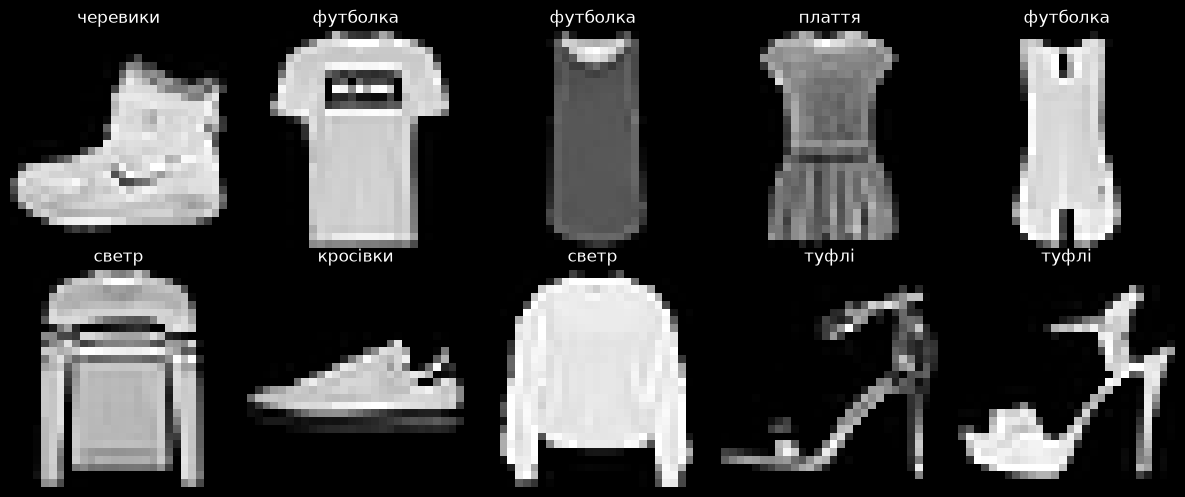

In [12]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

classes = ['футболка', 'штани', 'светр', 'плаття', 'пальто',
           'туфлі', 'сорочка', 'кросівки', 'сумка', 'черевики']

x_train_reshaped = x_train.reshape(60000, 784)
x_test_reshaped = x_test.reshape(10000, 784)

x_train_norm = x_train_reshaped / 255.0
x_test_norm = x_test_reshaped / 255.0

y_train_cat = utils.to_categorical(y_train, 10)
y_test_cat = utils.to_categorical(y_test, 10)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(classes[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

Архітектура моделі:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 800)            │       628,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 636,010 (2.43 MB)

 Trainable params: 636,010 (2.43 MB)

 Non-trainable params: 0 (0.00 B)


Починаємо навчання...
Epoch 1/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6463 - loss: 1.1967 - val_accuracy: 0.7372 - val_loss: 0.8410
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7587 - loss: 0.7667 - val_accuracy: 0.7792 - val_loss: 0.6997
Epoch 3/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7887 - loss: 0.6686 - val_accuracy: 0.7982 - val_loss: 0.6333
Epoch 4/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8050 - loss: 0.6153 - val_accuracy: 0.8095 - val_loss: 0.5931
Epoch 5/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8138 - loss: 0.5804 - val_accuracy: 0.8156 - val_loss: 0.5673
Epoch 6/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8211 - loss: 0.5548 - val_accuracy: 0.8171 - val_loss: 0.5470
Epoch 7/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8252 - loss: 0.5356 - val_accuracy: 0.8234 - val_loss: 0.5289
Epoch 8/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8291 - 

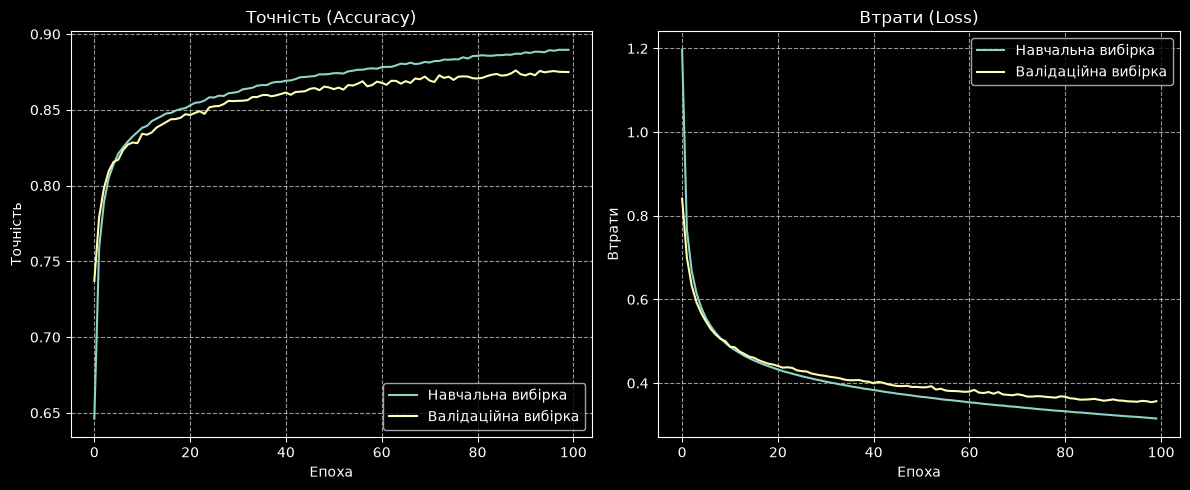

In [4]:
model = Sequential()

model.add(Input(shape=(784,)))
model.add(Dense(800, activation="relu"))
model.add(Dense(10, activation="softmax"))

# Компілюємо модель
model.compile(loss="categorical_crossentropy",
              optimizer="SGD",
              metrics=["accuracy"])

print("Архітектура моделі:")
model.summary()

print("\nПочинаємо навчання...")
history = model.fit(x_train_norm, y_train_cat,
                    batch_size=200,
                    epochs=100,
                    validation_split=0.2,
                    verbose=1)

scores = model.evaluate(x_test_norm, y_test_cat, verbose=1)
print(f"\nЧастка вірних відповідей на тестових даних, у відсотках: {round(scores[1] * 100, 4)}%")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Навчальна вибірка')
plt.plot(history.history['val_accuracy'], label='Валідаційна вибірка')
plt.title('Точність (Accuracy)')
plt.xlabel('Епоха')
plt.ylabel('Точність')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Навчальна вибірка')
plt.plot(history.history['val_loss'], label='Валідаційна вибірка')
plt.title('Втрати (Loss)')
plt.xlabel('Епоха')
plt.ylabel('Втрати')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

--- Дані з Fashion MNIST (Індекс 492) ---
Справжній клас: сумка
Розпізнаний клас: сумка

--- Власне зображення (dress.webp) ---
Розпізнаний клас: плаття (Впевненість: 30.74%)


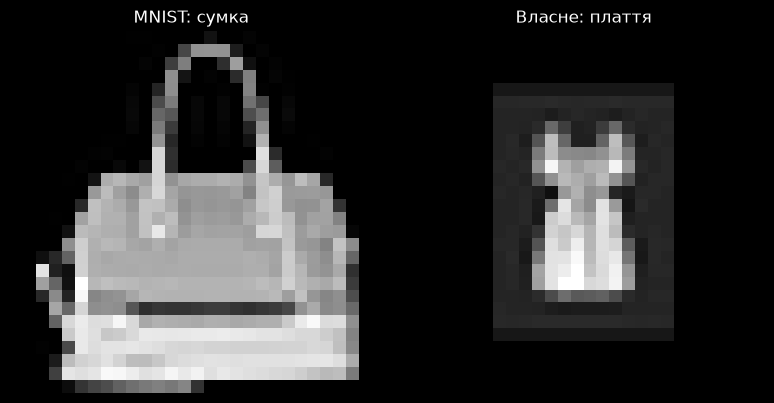

In [5]:
n_rec = 492
image_dataset = x_test[n_rec]
label_dataset = y_test[n_rec]

image_for_model = x_test_norm[n_rec].reshape(1, 784)

prediction_dataset = model.predict(image_for_model, verbose=0)
predicted_class_dataset = np.argmax(prediction_dataset)

print(f"--- Дані з Fashion MNIST (Індекс {n_rec}) ---")
print(f"Справжній клас: {classes[label_dataset]}")
print(f"Розпізнаний клас: {classes[predicted_class_dataset]}")

image_path = 'dress.webp'

try:
    img = Image.open(image_path).convert('L')

    img_inverted = ImageOps.invert(img)

    final_img = Image.new('L', (28, 28), color=0)

    img_inverted.thumbnail((20, 20), Image.Resampling.LANCZOS)

    offset_x = (28 - img_inverted.width) // 2
    offset_y = (28 - img_inverted.height) // 2
    final_img.paste(img_inverted, (offset_x, offset_y))

    img_array = np.array(final_img) / 255.0
    img_for_model = img_array.reshape(1, 784)

    prediction_custom = model.predict(img_for_model, verbose=0)
    predicted_class_custom = np.argmax(prediction_custom)
    confidence = np.max(prediction_custom) * 100

    print(f"\n--- Власне зображення ({image_path}) ---")
    print(f"Розпізнаний клас: {classes[predicted_class_custom]} (Впевненість: {confidence:.2f}%)")

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image_dataset, cmap='gray')
    plt.title(f"MNIST: {classes[predicted_class_dataset]}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_array, cmap='gray')
    plt.title(f"Власне: {classes[predicted_class_custom]}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Файл не знайдено.")

In [6]:
epochs_to_test = [50, 75, 100, 125]
results_epochs = {}

print("=== ЕКСПЕРИМЕНТ 1: Кількість епох ===")

for ep in epochs_to_test:
    print(f"Навчання на {ep} епохах...")
    start_time = time.time()

    test_model = Sequential()
    test_model.add(Input(shape=(784,)))
    test_model.add(Dense(800, activation="relu"))
    test_model.add(Dense(10, activation="softmax"))

    test_model.compile(loss="categorical_crossentropy",
                  optimizer="SGD",
                  metrics=["accuracy"])

    test_model.fit(x_train_norm, y_train_cat,
                   batch_size=200,
                   epochs=ep,
                   verbose=0)

    scores = test_model.evaluate(x_test_norm, y_test_cat, verbose=0)
    acc = round(scores[1] * 100, 4)
    train_time = round(time.time() - start_time, 2)

    results_epochs[ep] = acc
    print(f"Точність для {ep} епох: {acc}% (Час: {train_time} сек)")

best_epoch = max(results_epochs, key=results_epochs.get)
print(f"\nНайкращий результат досягнуто при {best_epoch} епохах.")

=== ЕКСПЕРИМЕНТ 1: Кількість епох ===
Навчання на 50 епохах...
Точність для 50 епох: 85.88% (Час: 38.28 сек)
Навчання на 75 епохах...
Точність для 75 епох: 86.74% (Час: 56.55 сек)
Навчання на 100 епохах...
Точність для 100 епох: 87.17% (Час: 77.41 сек)
Навчання на 125 епохах...
Точність для 125 епох: 87.42% (Час: 98.54 сек)

Найкращий результат досягнуто при 125 епохах.


In [7]:
batch_sizes_to_test = [50, 100, 200, 400]
results_batch = {}

print("=== ЕКСПЕРИМЕНТ 2: Розмір міні-вибірки ===")

for bs in batch_sizes_to_test:
    print(f"Навчання з batch_size = {bs}...")
    start_time = time.time()

    model_bs = Sequential()
    model_bs.add(Input(shape=(784,)))
    model_bs.add(Dense(800, activation="relu"))
    model_bs.add(Dense(10, activation="softmax"))

    model_bs.compile(loss="categorical_crossentropy", optimizer="SGD", metrics=["accuracy"])

    model_bs.fit(x_train_norm, y_train_cat, batch_size=bs, epochs=125, verbose=0)

    scores = model_bs.evaluate(x_test_norm, y_test_cat, verbose=0)
    acc = round(scores[1] * 100, 4)
    train_time = round(time.time() - start_time, 2)

    results_batch[bs] = acc
    print(f"Точність: {acc}% (Час навчання: {train_time} сек)")

best_bs = max(results_batch, key=results_batch.get)
print(f"\nНайкращий batch_size: {best_bs}")

=== ЕКСПЕРИМЕНТ 2: Розмір міні-вибірки ===
Навчання з batch_size = 50...
Точність: 88.98% (Час навчання: 177.02 сек)
Навчання з batch_size = 100...
Точність: 88.54% (Час навчання: 124.78 сек)
Навчання з batch_size = 200...
Точність: 87.46% (Час навчання: 98.51 сек)
Навчання з batch_size = 400...
Точність: 86.46% (Час навчання: 82.94 сек)

Найкращий batch_size: 50


In [8]:
neurons_to_test = [500, 700, 900, 1200]
results_neurons = {}

print("\n=== ЕКСПЕРИМЕНТ 3: Кількість нейронів вхідного шару ===")

for neurons in neurons_to_test:
    print(f"Навчання з {neurons} нейронами...")
    start_time = time.time()

    model_n = Sequential()
    model_n.add(Input(shape=(784,)))
    model_n.add(Dense(neurons, activation="relu"))
    model_n.add(Dense(10, activation="softmax"))

    model_n.compile(loss="categorical_crossentropy", optimizer="SGD", metrics=["accuracy"])

    model_n.fit(x_train_norm, y_train_cat, batch_size=200, epochs=125, verbose=0)

    scores = model_n.evaluate(x_test_norm, y_test_cat, verbose=0)
    acc = round(scores[1] * 100, 4)
    train_time = round(time.time() - start_time, 2)

    results_neurons[neurons] = acc
    print(f"Точність: {acc}% (Час: {train_time} сек)")

best_neurons = max(results_neurons, key=results_neurons.get)
print(f"\nНайкраща кількість нейронів: {best_neurons}")


=== ЕКСПЕРИМЕНТ 3: Кількість нейронів вхідного шару ===
Навчання з 500 нейронами...
Точність: 87.26% (Час: 72.63 сек)
Навчання з 700 нейронами...
Точність: 87.57% (Час: 90.37 сек)
Навчання з 900 нейронами...
Точність: 87.4% (Час: 109.43 сек)
Навчання з 1200 нейронами...
Точність: 87.49% (Час: 464.66 сек)

Найкраща кількість нейронів: 700


In [9]:
hidden_neurons = [500, 700, 900, 1200]
results_hidden = {}

print("=== ЕКСПЕРИМЕНТ 4: Додавання прихованого шару ===")

for hn in hidden_neurons:
    print(f"Навчання з додатковим шаром на {hn} нейронів...")
    start_time = time.time()

    model_h = Sequential()
    model_h.add(Input(shape=(784,)))
    model_h.add(Dense(800, activation="relu"))
    model_h.add(Dense(hn, activation="relu"))
    model_h.add(Dense(10, activation="softmax"))

    model_h.compile(loss="categorical_crossentropy", optimizer="SGD", metrics=["accuracy"])

    model_h.fit(x_train_norm, y_train_cat, batch_size=200, epochs=125, verbose=0)

    scores = model_h.evaluate(x_test_norm, y_test_cat, verbose=0)
    acc = round(scores[1] * 100, 4)
    train_time = round(time.time() - start_time, 2)

    results_hidden[hn] = acc
    print(f"Точність: {acc}% (Час: {train_time} сек)")

best_hidden = max(results_hidden, key=results_hidden.get)
print(f"\nНайкраща кількість нейронів прихованого шару: {best_hidden}")

=== ЕКСПЕРИМЕНТ 4: Додавання прихованого шару ===
Навчання з додатковим шаром на 500 нейронів...
Точність: 88.45% (Час: 173.49 сек)
Навчання з додатковим шаром на 700 нейронів...
Точність: 88.67% (Час: 202.2 сек)
Навчання з додатковим шаром на 900 нейронів...
Точність: 88.61% (Час: 237.43 сек)
Навчання з додатковим шаром на 1200 нейронів...
Точність: 88.31% (Час: 270.21 сек)

Найкраща кількість нейронів прихованого шару: 700


=== ФІНАЛЬНА ОПТИМІЗОВАНА МОДЕЛЬ ===


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 700)            │       549,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 700)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 500)            │       350,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 905,010 (3.45 MB)

 Trainable params: 905,010 (3.45 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/125
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6884 - loss: 0.9362 - val_accuracy: 0.7972 - val_loss: 0.5911
Epoch 2/125
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7900 - loss: 0.6154 - val_accuracy: 0.8260 - val_loss: 0.5163
Epoch 3/125
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8129 - loss: 0.5425 - val_accuracy: 0.8335 - val_loss: 0.4767
Epoch 4/125
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8275 - loss: 0.4995 - val_accuracy: 0.8412 - val_loss: 0.4468
Epoch 5/125
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8362 - loss: 0.4722 - val_accuracy: 0.8479 - val_loss: 0.4260
Epoch 6/125
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8411 - loss: 0.4508 - val_accuracy: 0.8547 - val_loss: 0.4152
Epoch 7/125
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8494 - loss: 0.4338 - val_accuracy: 0.8534 - val_loss: 0.4072
Epoch 8/125
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8533 - loss: 0.4198 - val

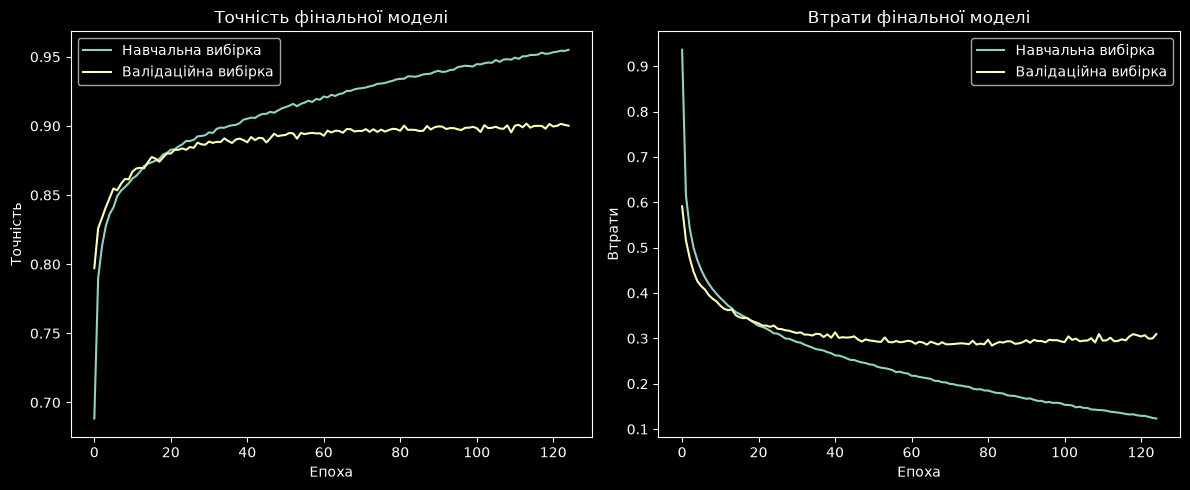

In [13]:
from tensorflow.keras.layers import Dropout
print("=== ФІНАЛЬНА ОПТИМІЗОВАНА МОДЕЛЬ ===")

final_model = Sequential()
final_model.add(Input(shape=(784,)))
final_model.add(Dense(700, activation="relu"))
final_model.add(Dropout(0.3))
final_model.add(Dense(500, activation="relu"))
final_model.add(Dropout(0.3))
final_model.add(Dense(10, activation="softmax"))

final_model.compile(loss="categorical_crossentropy",
                    optimizer="SGD",
                    metrics=["accuracy"])

print(final_model.summary())

history_final = final_model.fit(x_train_norm, y_train_cat,
                                batch_size=50,
                                epochs=125,
                                validation_split=0.2,
                                verbose=1)

scores_final = final_model.evaluate(x_test_norm, y_test_cat, verbose=1)
print(f"\nФінальна частка вірних відповідей: {round(scores_final[1] * 100, 4)}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_final.history['accuracy'], label='Навчальна вибірка')
plt.plot(history_final.history['val_accuracy'], label='Валідаційна вибірка')
plt.title('Точність фінальної моделі')
plt.xlabel('Епоха')
plt.ylabel('Точність')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_final.history['loss'], label='Навчальна вибірка')
plt.plot(history_final.history['val_loss'], label='Валідаційна вибірка')
plt.title('Втрати фінальної моделі')
plt.xlabel('Епоха')
plt.ylabel('Втрати')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
import os

final_model.save('fashion_mnist_dense.h5')
final_model.save('fashion_mnist_dense.keras')

print(f"Моделі успішно збережено у директорію: {os.getcwd()}")
print("Збережені файли:", [f for f in os.listdir() if 'fashion_mnist_dense' in f])

Моделі успішно збережено у директорію: /Users/bohdan_best/Documents/університет/4 курс/Deep Learning/lab1
Збережені файли: ['fashion_mnist_dense.keras', 'fashion_mnist_dense.h5']
